# E-Commerce Return Prediction — Exploratory Data Analysis

## Objective

This notebook explores the cleaned e-commerce transaction dataset to identify
patterns and relationships associated with product returns.

The analysis focuses on answering key business questions such as:

- What proportion of orders are returned?
- Which product categories have higher return rates?
- Are return rates different across customer locations?
- Do customer segments behave differently?
- Is there an association between discounts and returns?
- Does delivery time appear to be associated with returns?
- How does return behavior vary over time?
- Which variables may provide useful predictive signals for the ML stage?

### Analysis Pipeline

**Clean Dataset → Univariate Analysis → Return Analysis → Relationship Analysis
→ Business Insights → ML Feature Considerations**

## 1. Business Context

Product returns are an important operational and financial consideration for
e-commerce businesses.

A high return rate can increase:

- Reverse-logistics costs
- Refund processing costs
- Inventory handling requirements
- Customer-support workload
- Operational complexity

The objective of this exploratory analysis is therefore not simply to
describe the dataset, but to identify **actionable patterns in return
behavior**.

### Central Business Question

> **Which customer, product, geographic, promotional, and operational
> characteristics are associated with higher e-commerce return rates?**

The findings from this analysis will be used to guide the machine-learning
stage and the Power BI dashboard.

## Import Required Libraries

The following Python libraries are used for data loading, statistical
analysis, visualization, and exploratory analysis.

The analysis primarily uses:

- Pandas for data manipulation
- NumPy for numerical operations
- Matplotlib and Seaborn for visualization

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned/ecommerce_cleaned.csv")

df.head()

,orderid,orderdate,productcategory,quantity,priceperunit,paymentmethod,customerlocation,customersegment,discountapplied,deliverytimedays,isreturned,totalamount,order_month
0,Ord100000,2023-06-26,Electronics,4,3968.220,Credit Card,Bangalore,New,0.18,4.0,0,13015.76,6
1,Ord100001,2023-09-24,Books,3,1554.250,Net Banking,Chennai,New,0.20,5.0,1,3730.20,9
2,Ord100002,2023-12-07,Books,4,2752.710,Cash On Delivery,Delhi,Vip,0.05,5.0,1,10460.30,12
3,Ord100003,2023-10-09,Books,1,2765.735,Credit Card,Chennai,New,0.29,1.0,0,1963.67,10
4,Ord100004,2023-03-04,Books,2,2765.735,Net Banking,Chennai,Regular,0.16,7.0,0,4646.43,3


## Dataset Overview

Before performing detailed analysis, the cleaned dataset is inspected to
understand:

- Number of observations
- Number of variables
- Data types
- Numerical variables
- Categorical variables
- Target variable distribution

This provides context for interpreting the subsequent analysis.

In [3]:
df["orderdate"] = pd.to_datetime(df["orderdate"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   orderid           1000 non-null   object        
 1   orderdate         1000 non-null   datetime64[ns]
 2   productcategory   1000 non-null   object        
 3   quantity          1000 non-null   int64         
 4   priceperunit      1000 non-null   float64       
 5   paymentmethod     1000 non-null   object        
 6   customerlocation  1000 non-null   object        
 7   customersegment   1000 non-null   object        
 8   discountapplied   1000 non-null   float64       
 9   deliverytimedays  1000 non-null   float64       
 10  isreturned        1000 non-null   int64         
 11  totalamount       1000 non-null   float64       
 12  order_month       1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(5)
memory usage: 101.7+ KB


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Number of rows: 1000
Number of columns: 13

Columns:
['orderid', 'orderdate', 'productcategory', 'quantity', 'priceperunit', 'paymentmethod', 'customerlocation', 'customersegment', 'discountapplied', 'deliverytimedays', 'isreturned', 'totalamount', 'order_month']


In [5]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate Order IDs:", df["orderid"].duplicated().sum())

Missing values: 0
Duplicate Order IDs: 0


## Overall Return Distribution

The target variable `isreturned` represents whether an order was returned.

Understanding the target distribution is important because:

1. It establishes the overall scale of the return problem.
2. It determines whether the classification problem is balanced.
3. It provides a baseline for interpreting machine-learning performance.

### Target Definition

```text
0 → Order was not returned
1 → Order was returned

In [6]:
return_counts = df["isreturned"].value_counts()

return_counts

isreturned
0    646
1    354
Name: count, dtype: int64

In [7]:
total_orders = len(df)

returned_orders = df["isreturned"].sum()

return_rate = (
    returned_orders / total_orders
) * 100

print(f"Total Orders: {total_orders:,}")
print(f"Returned Orders: {returned_orders:,}")
print(f"Return Rate: {return_rate:.2f}%")

Total Orders: 1,000
Returned Orders: 354
Return Rate: 35.40%


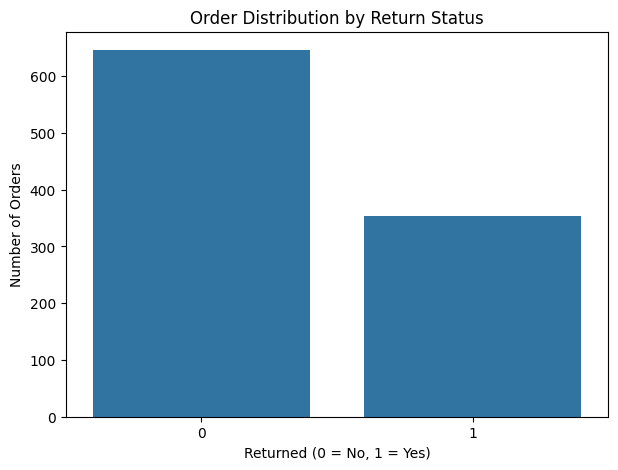

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="isreturned"
)

plt.title("Order Distribution by Return Status")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Number of Orders")

plt.show()

### Business Interpretation

Approximately **35.4% of orders in the dataset were returned**.

This indicates that returns represent a significant proportion of order
activity in the dataset and therefore justify further investigation into
the factors associated with return behavior.

In [9]:
category_returns = (
    df.groupby("productcategory")
      .agg(
          total_orders=("isreturned", "size"),
          returned_orders=("isreturned", "sum"),
          return_rate=("isreturned", "mean")
      )
      .reset_index()
)

category_returns["return_rate"] *= 100

category_returns = category_returns.sort_values(
    "return_rate",
    ascending=False
)

category_returns

,productcategory,total_orders,returned_orders,return_rate
5,Toys,153,60,39.215686
1,Books,172,67,38.953488
3,Fashion,144,52,36.111111
4,Home & Kitchen,172,58,33.720930
0,Beauty,162,54,33.333333
2,Electronics,197,63,31.979695


### Orders by Product Category

The number of orders in each product category is examined to understand the
product mix represented in the dataset.

This provides important context when comparing return rates.

For example, a category with a high number of returns may simply have a
larger number of orders. Therefore, **return counts alone are not sufficient;
return rate is used for meaningful comparisons.**

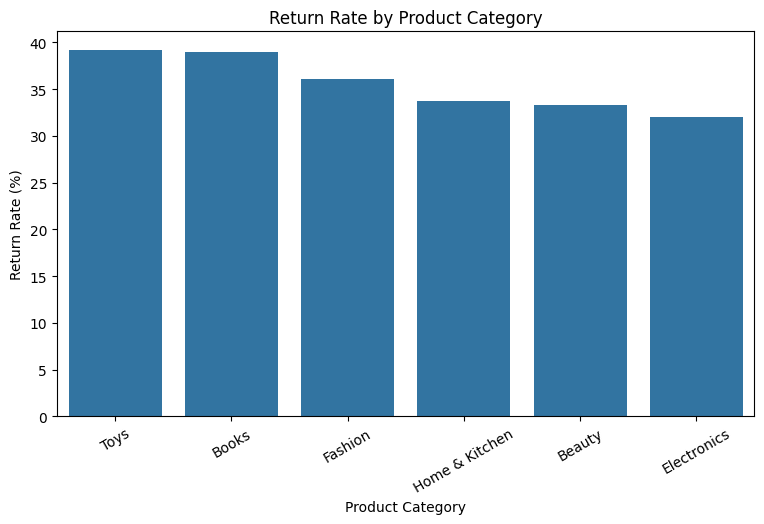

In [10]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_returns,
    x="productcategory",
    y="return_rate"
)

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=30)

plt.show()

### Finding

Toys and Books show comparatively higher return rates, while Electronics shows a comparatively lower return rate in this dataset.

In [11]:
location_returns = (
    df.groupby("customerlocation")
      .agg(
          total_orders=("isreturned", "size"),
          returned_orders=("isreturned", "sum"),
          return_rate=("isreturned", "mean")
      )
      .reset_index()
)

location_returns["return_rate"] *= 100

location_returns = location_returns.sort_values(
    "return_rate",
    ascending=False
)

location_returns

,customerlocation,total_orders,returned_orders,return_rate
5,Pune,165,73,44.242424
0,Bangalore,165,62,37.575758
4,Mumbai,165,57,34.545455
1,Chennai,174,59,33.908046
2,Delhi,173,57,32.947977
3,Hyderabad,158,46,29.113924


### Orders by Customer Location

Customer location is retained as an analytical variable because geographic
variation may reveal differences in return behavior.

The analysis will compare both:

- Order volume by location
- Return rate by location

Geographic differences will be interpreted as **associations**, not causal
relationships.

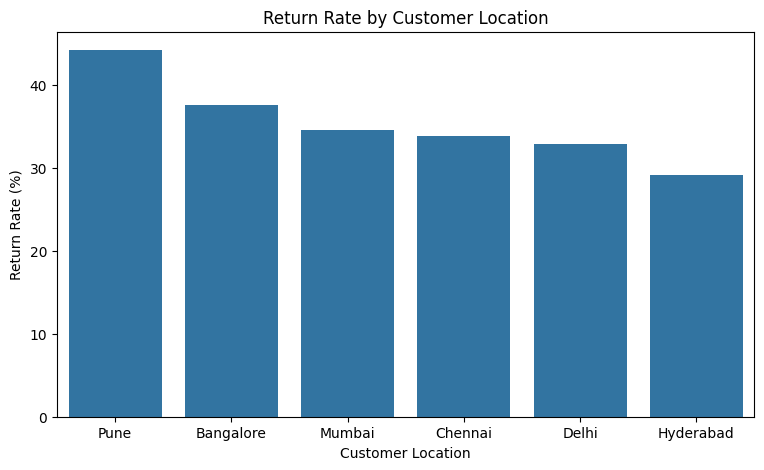

In [12]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=location_returns,
    x="customerlocation",
    y="return_rate"
)

plt.title("Return Rate by Customer Location")
plt.xlabel("Customer Location")
plt.ylabel("Return Rate (%)")

plt.show()

### Finding

Pune shows the highest observed return rate, while Hyderabad shows the
lowest in the dataset.

In [13]:
segment_returns = (
    df.groupby("customersegment")
      .agg(
          total_orders=("isreturned", "size"),
          returned_orders=("isreturned", "sum"),
          return_rate=("isreturned", "mean")
      )
      .reset_index()
)

segment_returns["return_rate"] *= 100

segment_returns.sort_values(
    "return_rate",
    ascending=False
)

,customersegment,total_orders,returned_orders,return_rate
1,Regular,353,132,37.393768
2,Vip,292,103,35.273973
0,New,355,119,33.521127


### Orders by Customer Segment

The distribution of New, Regular, and VIP customers is examined to
understand the customer composition of the dataset.

Return rates will then be compared across these segments to determine
whether customer segment provides meaningful differentiation.

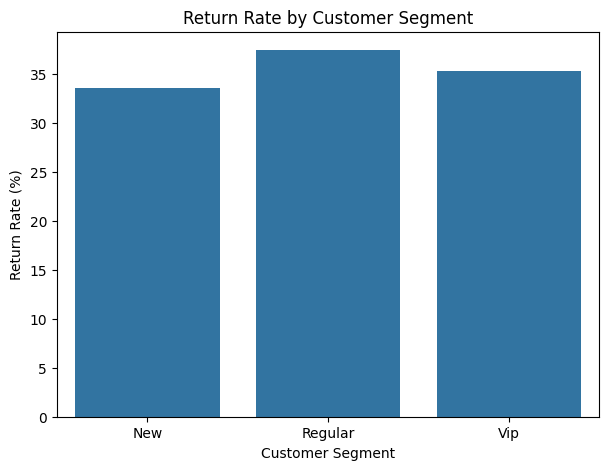

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=segment_returns,
    x="customersegment",
    y="return_rate"
)

plt.title("Return Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Return Rate (%)")

plt.show()

### Finding

Return rates are relatively similar across New, Regular, and VIP customer
segments.

## Return Rate by Payment Method

### Business Question

> **Is return behavior noticeably different across payment methods?**

Return rates are compared across payment methods to determine whether
payment behavior provides a meaningful signal.

In [15]:
payment_returns = (
    df.groupby("paymentmethod")
      .agg(
          total_orders=("isreturned", "size"),
          returned_orders=("isreturned", "sum"),
          return_rate=("isreturned", "mean")
      )
      .reset_index()
)

payment_returns["return_rate"] *= 100

payment_returns.sort_values(
    "return_rate",
    ascending=False
)

,paymentmethod,total_orders,returned_orders,return_rate
0,Cash On Delivery,250,91,36.400000
3,Upi,239,85,35.564854
1,Credit Card,241,84,34.854772
2,Net Banking,270,94,34.814815


## Return Rate by Discount Level

### Business Question

> **Are discounted orders more likely to be returned?**

Discount values are grouped into business-friendly categories:

- No Discount
- Low Discount
- Medium Discount
- High Discount

Return rates are then compared across these groups.

This analysis is intended to investigate whether promotional activity is
associated with return behavior.

In [16]:
df["discount_category"] = pd.cut(
    df["discountapplied"],
    bins=[-0.001, 0, 0.10, 0.20, 1],
    labels=[
        "No Discount",
        "Low Discount",
        "Medium Discount",
        "High Discount"
    ]
)

df["discount_category"].value_counts()

discount_category
Low Discount       355
Medium Discount    323
High Discount      305
No Discount         17
Name: count, dtype: int64

In [17]:
discount_returns = (
    df.groupby("discount_category", observed=False)
      .agg(
          total_orders=("isreturned", "size"),
          returned_orders=("isreturned", "sum"),
          return_rate=("isreturned", "mean")
      )
      .reset_index()
)

discount_returns["return_rate"] *= 100

discount_returns

,discount_category,total_orders,returned_orders,return_rate
0,No Discount,17,4,23.529412
1,Low Discount,355,126,35.492958
2,Medium Discount,323,112,34.674923
3,High Discount,305,112,36.721311


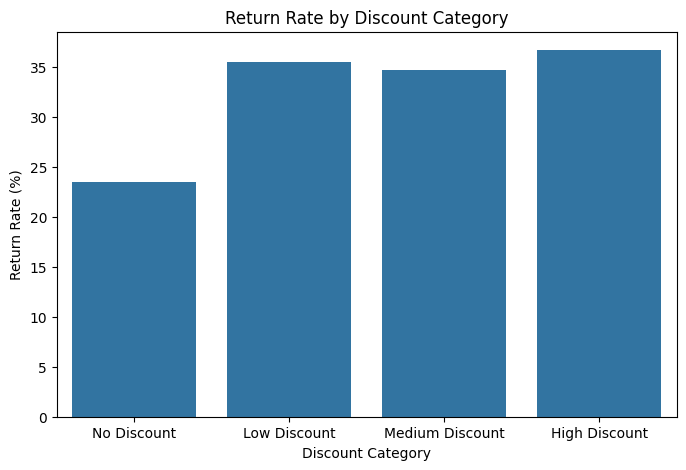

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=discount_returns,
    x="discount_category",
    y="return_rate"
)

plt.title("Return Rate by Discount Category")
plt.xlabel("Discount Category")
plt.ylabel("Return Rate (%)")

plt.show()

### Finding

High-discount orders show a slightly higher return rate than lower-discount
orders in the dataset.

### Business Interpretation

This may indicate that heavily discounted purchases could have different
customer behavior or purchase intent.

Possible explanations include:

- Impulse purchasing
- Promotional purchases
- Lower purchase commitment
- Mismatch between expectations and products

However, this is an association and does not demonstrate that discounts
cause returns.

Further analysis using customer history and promotion-level data would be
required.

## Return Rate by Delivery Time

### Business Question

> **Does delivery duration appear to influence return behavior?**

Delivery time is grouped into:

- 1–3 Days
- 4–6 Days
- 7+ Days

Return rates are compared across these groups.

In [19]:
df["delivery_category"] = pd.cut(
    df["deliverytimedays"],
    bins=[-np.inf, 3, 6, np.inf],
    labels=[
        "1-3 Days",
        "4-6 Days",
        "7+ Days"
    ]
)

In [20]:
delivery_returns = (
    df.groupby("delivery_category", observed=False)
      .agg(
          total_orders=("isreturned", "size"),
          returned_orders=("isreturned", "sum"),
          return_rate=("isreturned", "mean")
      )
      .reset_index()
)

delivery_returns["return_rate"] *= 100

delivery_returns

,delivery_category,total_orders,returned_orders,return_rate
0,1-3 Days,328,123,37.500000
1,4-6 Days,369,124,33.604336
2,7+ Days,303,107,35.313531


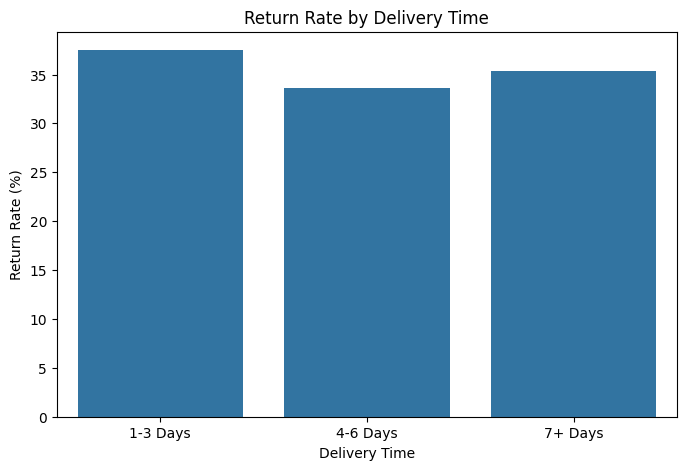

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=delivery_returns,
    x="delivery_category",
    y="return_rate"
)

plt.title("Return Rate by Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Return Rate (%)")

plt.show()

## Temporal Analysis

### Business Question

> **Does return behavior vary over time?**

Monthly return rates are analyzed to identify potential temporal patterns.

Temporal analysis can help identify:

- Seasonal variation
- Periods of unusually high return activity
- Changes in customer behavior
- Potential promotional or operational effects

In [22]:
monthly_returns = (
    df.groupby("order_month")
      .agg(
          total_orders=("isreturned", "size"),
          returned_orders=("isreturned", "sum"),
          return_rate=("isreturned", "mean")
      )
      .reset_index()
)

monthly_returns["return_rate"] *= 100

monthly_returns

,order_month,total_orders,returned_orders,return_rate
0,1,97,34,35.051546
1,2,80,33,41.250000
2,3,77,21,27.272727
3,4,86,32,37.209302
4,5,73,22,30.136986
5,6,84,24,28.571429
6,7,69,28,40.579710
7,8,94,32,34.042553
8,9,77,32,41.558442
9,10,88,32,36.363636


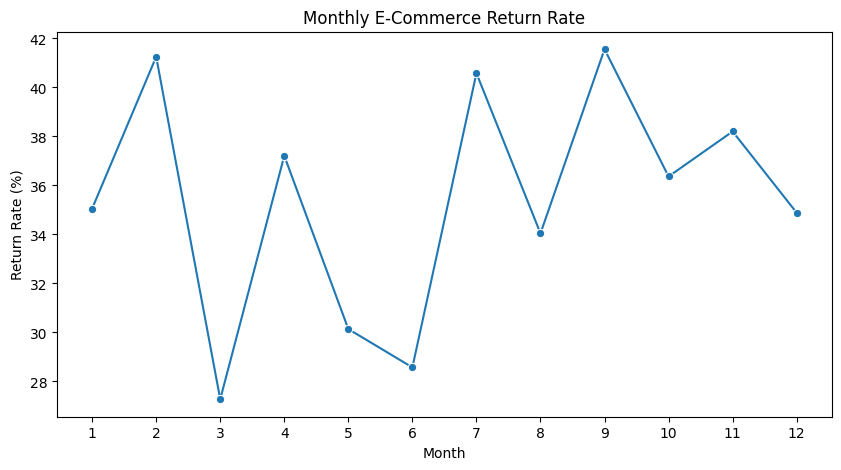

In [23]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_returns,
    x="order_month",
    y="return_rate",
    marker="o"
)

plt.title("Monthly E-Commerce Return Rate")
plt.xlabel("Month")
plt.ylabel("Return Rate (%)")
plt.xticks(range(1, 13))

plt.show()

### Interpretation

The monthly return-rate trend shows variation across the observation
period.

Periods with unusually high or low return rates may warrant additional
investigation into:

- Promotional campaigns
- Product mix
- Customer purchasing behavior
- Operational changes
- Seasonal effects

Because the dataset covers a limited period, these patterns should not be
interpreted as established seasonal trends without additional historical
data.

In [24]:
numeric_features = [
    "quantity",
    "priceperunit",
    "discountapplied",
    "deliverytimedays",
    "totalamount"
]

df.groupby("isreturned")[numeric_features].mean().round(2)

,quantity,priceperunit,discountapplied,deliverytimedays,totalamount
isreturned,,,,,
0,2.43,2579.40,0.15,4.96,5312.71
1,2.51,2547.67,0.15,4.83,5445.13


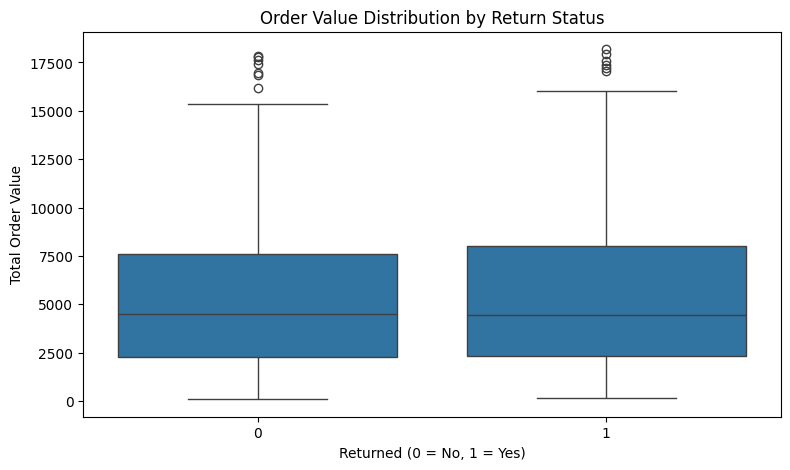

In [25]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="isreturned",
    y="totalamount"
)

plt.title("Order Value Distribution by Return Status")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Total Order Value")

plt.show()

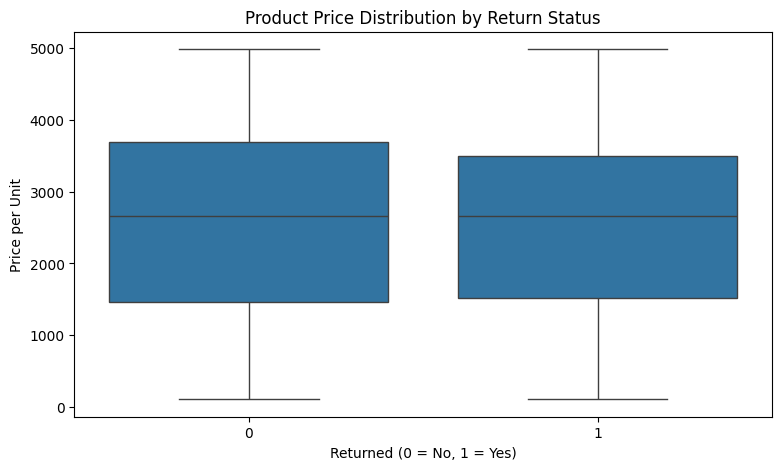

In [26]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="isreturned",
    y="priceperunit"
)

plt.title("Product Price Distribution by Return Status")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Price per Unit")

plt.show()

## Correlation Analysis

Correlation analysis is used to examine relationships between numerical
variables.

The analysis includes variables such as:

- Quantity
- Price per unit
- Discount
- Delivery time
- Total amount
- Return indicator

Correlation can help identify potentially useful relationships, but
correlation does not imply causation.

Categorical variables require separate analysis because simple Pearson
correlation is not directly appropriate for nominal categories.

In [27]:
correlation_features = [
    "quantity",
    "priceperunit",
    "discountapplied",
    "deliverytimedays",
    "totalamount",
    "isreturned"
]

correlation_matrix = df[
    correlation_features
].corr()

correlation_matrix

,quantity,priceperunit,discountapplied,deliverytimedays,totalamount,isreturned
quantity,1.000000,-0.011010,0.034975,-0.069840,0.598259,0.031976
priceperunit,-0.011010,1.000000,-0.011873,0.023848,0.715502,-0.011429
discountapplied,0.034975,-0.011873,1.000000,-0.033420,-0.106482,0.007929
deliverytimedays,-0.069840,0.023848,-0.033420,1.000000,-0.015729,-0.023760
totalamount,0.598259,0.715502,-0.106482,-0.015729,1.000000,0.016407
isreturned,0.031976,-0.011429,0.007929,-0.023760,0.016407,1.000000


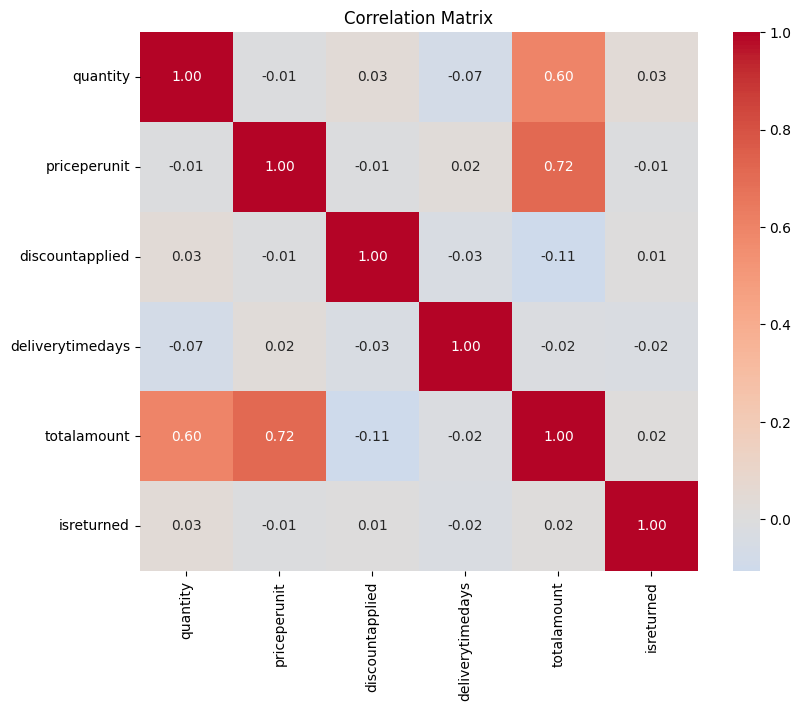

In [28]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [29]:
insights_summary = pd.DataFrame({
    "Analysis": [
        "Overall Return Rate",
        "Highest Return Category",
        "Lowest Return Category",
        "Highest Return Location",
        "Lowest Return Location",
        "Highest Major Discount Band",
        "Highest Return Month",
        "Lowest Return Month"
    ],

    "Finding": [
        f"{df['isreturned'].mean() * 100:.2f}%",

        category_returns.iloc[0]["productcategory"],

        category_returns.iloc[-1]["productcategory"],

        location_returns.iloc[0]["customerlocation"],

        location_returns.iloc[-1]["customerlocation"],

        discount_returns.iloc[1:]["return_rate"].max(),

        monthly_returns.loc[
            monthly_returns["return_rate"].idxmax(),
            "order_month"
        ],

        monthly_returns.loc[
            monthly_returns["return_rate"].idxmin(),
            "order_month"
        ]
    ]
})

insights_summary

,Analysis,Finding
0,Overall Return Rate,35.40%
1,Highest Return Category,Toys
2,Lowest Return Category,Electronics
3,Highest Return Location,Pune
4,Lowest Return Location,Hyderabad
5,Highest Major Discount Band,36.721311
6,Highest Return Month,9
7,Lowest Return Month,3


# 13. Key Findings

The exploratory analysis produced the following major observations:

### 1. Returns are significant

Approximately **35.4% of orders were returned** in the dataset.

### 2. Product category differences exist

Toys and Books showed comparatively higher return rates.

### 3. Geographic variation exists

Pune showed the highest observed return rate, while Hyderabad showed the
lowest.

### 4. Customer segment is not a major differentiator

Return rates were relatively similar across New, Regular, and VIP
customers.

### 5. Discounting warrants investigation

High-discount orders showed a slightly higher return rate.

### 6. Delivery time does not provide a straightforward business pattern

Return rates did not show a simple monotonic relationship with delivery
duration.

### 7. Temporal variation exists

Return rates varied across months, although the limited observation period
prevents strong conclusions about seasonality.

In [30]:
from pathlib import Path

Path("../outputs").mkdir(
    parents=True,
    exist_ok=True
)

In [31]:
category_returns.to_csv(
    "../outputs/return_rate_by_category.csv",
    index=False
)

location_returns.to_csv(
    "../outputs/return_rate_by_location.csv",
    index=False
)

segment_returns.to_csv(
    "../outputs/return_rate_by_segment.csv",
    index=False
)

discount_returns.to_csv(
    "../outputs/return_rate_by_discount.csv",
    index=False
)

delivery_returns.to_csv(
    "../outputs/return_rate_by_delivery.csv",
    index=False
)

monthly_returns.to_csv(
    "../outputs/monthly_return_trend.csv",
    index=False
)